In [118]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

#load the necessary odometry modules
from cpsl_datasets.cpsl_ds import CpslDS
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.dynamic_obj_tracking_tb import DynamicObjTrackingTB
# from odometry.test_benches.dynamic_obj_tracking_tb import _TestBench
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator
from odometry.point_cloud_processing.temporal_pc_stacker import temporalPcStacker
from odometry.point_cloud_processing.dynamic_object_tracker import DynamicObjectTracker


In [119]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")
GENERATED_DATASETS_PATH=os.getenv("GENERATED_DATASETS_PATH")

#setup the datasets
folder_name = "WILK"
# folder_name = "WILK_BASEMENT"
file_name = "WILK_Multipath_Test_5" #for point cloud comparison (frame 1340)
# file_name = "WILK_Path_1_Same_Side_Dynamic_1"
# file_name = "wilk_basement_3" #wilk_basement_2 for point cloud processing (frame 780)

config_label = "RaGNNarok_1fp_20fh_0_50_th_5mRng_0_2_res"
working_dir_path = "/home/david/Documents/odometry/submodules/mmwave_model_integrator/scripts/working_dir/RaGNNarok"

dataset = CpslDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilkinson.yaml"#"wilkinson.yaml"""wilk_basement_revB.yaml"
)

found 2886 radar samples
found 2886 lidar samples
found 2886 camera samples
found 2886 imu (orientation only) samples
found 2886imu (full data) samples
found 2886 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml
loaded map free space from /data/radnav/maps/wilkinson.yaml


In [120]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.5,#originally 0.1
    icp_best_points_percentile=80, #originally 65 ->80
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=0 #originally 1.5
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1, #was 0.6, try 0.1
    icp_best_points_percentile=50, #was 50 - try 75
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #was 0.25, try 1.0
)

In [ ]:
#initialize the point cloud stacker
pc_stacker = temporalPcStacker(
    num_frames_static_history = 4, # originally 4
    num_frames_dynamic_history = 0, # originally 0
    refresh_distance_m = 3, #originally 3
    refresh_rot_deg = 90, #originally 90
    refresh_time_s = 5, #originally 5
    grid_resolution_m = 5e-2, #originally 5e-2
    grid_max_distance_m = 20, #originally 20
    multi_path_clustering_eps = 0.5, #originally 0.5
    multi_path_clustering_min_samples = 15,  #originally 15
    multi_path_num_frames_history=4, # originally 4
    vel_filtering_enabled = True,
    vel_filtering_v_thresh = 0.05, # originally 0.05
    vel_filtering_min_static_rejection_radius = 0.25, #originally 0.25
    vel_filtering_dynamic_cluster_eps = 0.5, #originally 0.5
    vel_filtering_dynamic_cluster_min_samples = 15, #originally 15
    min_detection_radius_m=1.5, #originally 1.5
    max_detection_range_m=20, #originally 20
    gyro_bias=-0.0024 #originally -0.0024
)

#initialize the dynamic point cloud processor
dynamic_object_tracker = DynamicObjectTracker(
    vel_filtering_v_thresh=0.05,
    dbscan_eps=0.5, # originally 0.3
    dbscan_min_samples=3 # originally 5
)

dynamic_object_tracker.init_xy_tracker(
    threshold_confirmed=10,   
    threshold_coast=5.0,     
    v_max=3.0,             
    assign_metric="center_dist",
    # assign_radius=1.0,
    assign_radius=0.5,
    # P0=np.diag([1, 1, 5, 5]) ** 2,
    P0 = np.diag([0.5, 0.5, 2.0, 2.0]) ** 2  # was [1,1,5,5]
) 

loaded map with 20750 points
gt icp estimated heading:-5.708390622483 deg, pose:[-0.06546079  0.21857452]
loaded map with 20750 points


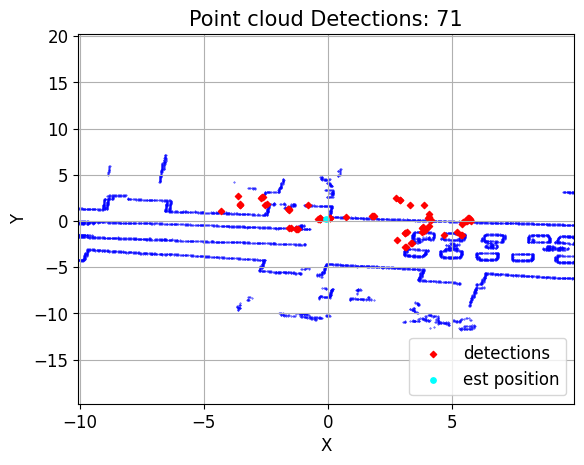

In [122]:
# test_bench = _TestBench(
test_bench = DynamicObjTrackingTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    dynamic_object_tracker=dynamic_object_tracker
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=test_bench.get_dataset_start_time(idx=0),
    gyro_bias=-0.0024 #originally -0.0024
)


found temp dir: /home/yili/Downloads/radnav_temp_dir
clearing temp directory /home/yili/Downloads/radnav_temp_dir


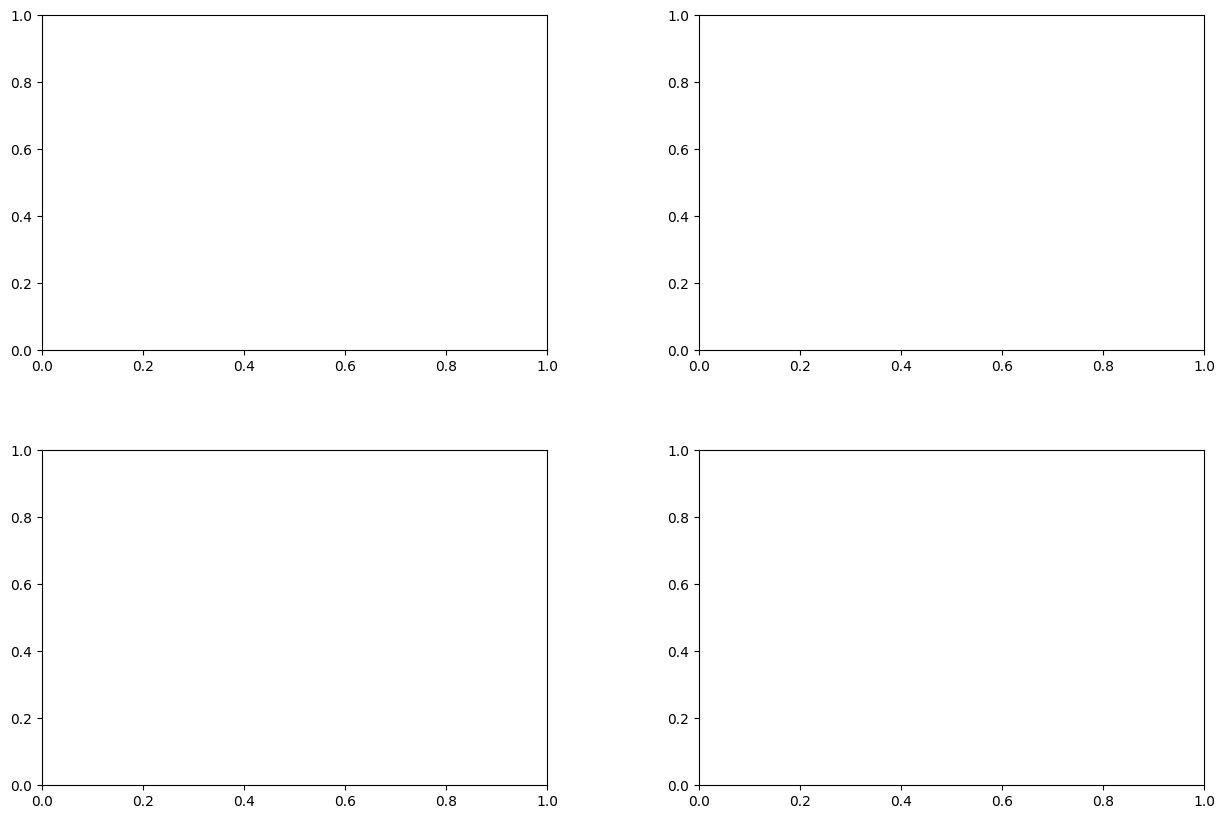

In [123]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=2,
    figsize=(15,10)
)

In [124]:


end_idx = dataset.num_frames//5 # for full dataset, use "dataset.num_frames" #point cloud sample: frame 1340 on Wilk_Multipath_test_5 (now 960)
save_name = file_name + "radar_test_more_clusters_more_tracks"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=False, #if not desired set to False
    # movie_generator= movie_generator) #if not desired, set to None
    movie_generator= None) #if not desired, set to None

#run to around 1:07 mark for looking at the point cloud

 12%|█▏        | 71/577 [00:00<00:00, 1490.18it/s]


RuntimeError: xy_tracker not initialized. Please call `init_xy_tracker()` first.

In [ ]:
dynamic_object_tracker.current_tracks

In [ ]:
test_bench.plot_compilation(
    show=True,
    idx=end_idx -1
)

In [ ]:
#evaluating processing times
update_periods = np.array(test_bench.history_update_periods)
processing_times = np.array(test_bench.history_update_actitve_compute_times)

percent_processing_times = 100 * np.divide(processing_times, update_periods)
# np.save("processing_times/radnav.npy",percent_processing_times)

In [ ]:
#save trajectories
# np.save("Trajectories/gt.npy",test_bench.history_position_m_gt)
# np.save("Trajectories/radnav.npy",test_bench.history_position_m)

In [ ]:

movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=20)

The following points belongs to a single frame. A K-distance plot is created to identify appropriate parameters for the cluster.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Example points
points = np.array([
    [13.6776876, -2.76749454], [13.54805174, -3.09493996], [13.54573125, -3.12980137],
    [13.54945349, -3.16594041], [13.54980561, -3.20010433], [12.78214064, -4.11982109],
    [12.72758333, -4.12406814], [12.70643713, -4.15242407], [12.68529092, -4.18078],
    [12.69924088, -4.23423237], [12.67977974, -4.26357586], [11.15069364, -5.79878677],
    [12.26774717, -4.52240432], [11.12716488, -5.82348252], [11.00543871, -6.36337827],
    [10.88028164, -6.31040212], [12.58255768, -4.09340519], [12.55902892, -4.11810094],
    [12.57001619, -4.17660849], [12.50999627, -4.17086256], [11.19804122, -5.74503759],
    [10.9631463, -6.42009013], [10.83560668, -6.36345381], [12.56084483, -4.26178691],
    [11.32838432, -5.94367482], [13.52486836, -3.08814441], [13.5104624, -3.12045057],
    [13.44027007, -3.07025768], [13.40471115, -3.06526456], [10.75471713, -6.25039569],
    [12.37510111, -7.17062255], [12.43743606, -6.52347667]
])

# Compute nearest neighbors
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(points)
distances, indices = neighbors_fit.kneighbors(points)

# Sort distances for plotting
distances = np.sort(distances[:, 3], axis=0)  # Use the 4th neighbor
plt.plot(distances)
plt.title("K-Distance Plot")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()


In [ ]:
# test_bench.dynamic_object_tracker.history_clustered_dynamic_clusters_nums

In [ ]:
# test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids

In [ ]:
# from tqdm import tqdm
# import matplotlib.pyplot as plt

# # Determine the number of rows and columns for the subplots
# r = int(150 / 2) + 1  # Adjusted to handle a maximum of 100 frames
# c = 2

# # Create subplots with specified figure size
# fig, axs = plt.subplots(r, c, figsize=(20, 5 * r))

# # Ensure axs is a 2D array even if rows or columns are 1
# if r == 1 or c == 1:
#     axs = axs.reshape(r, c)

# # Flatten axs to handle indexing easily
# axs = axs.flatten()

# # Initialize subplot index
# subplot_idx = 0

# # Set marker size for the plot
# test_bench.plotter_localization.marker_size = 0.5

# # Counter for valid (non-empty) frames
# valid_frame_count = 0

# # Iterate over the history of dynamic objects
# for idx in tqdm(range(len(test_bench.dynamic_object_tracker.history_dynamic_objects))):
#     # Stop after displaying 100 non-empty frames
#     if valid_frame_count >= 200:
#         break

#     # Get the current frame's dynamic objects
#     current_points = test_bench.dynamic_object_tracker.history_dynamic_objects[idx]

#     # Skip empty frames
#     if current_points.shape[0] < 1:
#         print(f"Skipping empty frame {idx}")
#         continue

#     # Plot the detections on the map
#     test_bench.plotter_localization.plot_detections_on_map(
#         current_points=current_points,
#         ax=axs[subplot_idx],  # Use the flattened subplot index
#         show=False,
#         # frame_number=idx,
#     )

#     # Set the limits for the subplot
#     axs[subplot_idx].set_ylim(-5, 5)
#     axs[subplot_idx].set_xlim(-10, 10)
#     axs[subplot_idx].set_title(f"Point Cloud Detection {current_points.shape[0]} | Frames {idx}")  # Add title for each frame

#     # Increment the subplot index and valid frame counter
#     subplot_idx += 1
#     valid_frame_count += 1

# # Adjust layout to prevent overlap and display the plots
# plt.tight_layout()
# plt.show()


In [ ]:
# current_centroids = test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids[100]
# centroid_points = np.array(list(current_centroids.values()))
# print(centroid_points)

In [ ]:
frames_data = []

for frame_centroids in test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids:
    frames_data.append(np.array(list(frame_centroids.values())))


In [ ]:
len(frames_data)

In [ ]:
import pickle

# Save frames_data as a pickle file
with open('frames_data.pkl', 'wb') as f:
    pickle.dump(frames_data, f)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from avstack.datastructs import DataContainer
from avstack.geometry import GlobalOrigin2D
from avstack.modules.perception.detections import CentroidDetection
from avstack.modules.tracking import BasicXyTracker

# # Initialize the tracker
# P0 = np.diag([1, 1, 5, 5]) ** 2
# tracker = BasicXyTracker(
#     threshold_confirmed=10,   # Minimum hits to confirm a track
#     threshold_coast=5.0,     # Maximum frames without updates before deletion
#     v_max=10.0,              # Maximum allowed velocity
#     assign_metric="center_dist",
#     assign_radius=1.0,
#     P0=P0,
# )


# Initialize the tracker
P0 = np.diag([1, 1, 5, 5]) ** 2
dynamic_object_tracker.init_xy_tracker(
    threshold_confirmed=10,   # Minimum hits to confirm a track
    threshold_coast=5.0,     # Maximum frames without updates before deletion
    v_max=10.0,              # Maximum allowed velocity
    assign_metric="center_dist",
    assign_radius=0.5,  #1.0,
    P0=P0,
)

In [ ]:
# imu_data = dataset.get_imu_full_data(idx=0)
# current_imu_data = dataset.get_imu_full_data(idx=5)
# print(current_imu_data[-1][0] - imu_data[-1][0])


In [ ]:

from collections import defaultdict
import matplotlib.pyplot as plt

tracker = DynamicObjectTracker()
tracker.init_xy_tracker()

imu_data = dataset.get_imu_full_data(idx=0)
initial_timestamp = imu_data[-1][0]

for i_frame, centroids_dict in enumerate(frames_data):  # frames_data: list of {id: centroid}
    current_imu_data = dataset.get_imu_full_data(idx=i_frame)
    current_timestamp = current_imu_data[-1][0]
    # timestamp = current_timestamp - initial_timestamp

    tracker.update_tracks(i_frame=i_frame, centroids_dict=centroids_dict, timestamp=current_timestamp)


In [ ]:
track_history_active = tracker.track_history  # dict: track_id -> [[frame, x, y], ...]

print(f"{'ID':<4} {'confirmed':<10} {'active':<8} {'dt_coast':<10}")
for trk in tracker.xy_tracker.tracks:
    print(f"{trk.ID:<4} {str(trk.confirmed):<10} {str(trk.active):<8} {trk.dt_coast:<10}")


In [ ]:
print(tracker.xy_tracker.confirmed_tracks)

In [ ]:
track_history_full = tracker.track_history_full  # dict: track_id -> [[frame, x, y], ...]

tracker.plot_tracks_on_map(tracks=track_history_full, map_handler=map_handler)

In [ ]:
track_history = tracker.track_history  # dict: track_id -> [[frame, x, y], ...]

tracker.plot_tracks_on_map(tracks=track_history, map_handler=map_handler)

In [ ]:
track_history_full = tracker.track_history_full  # dict: track_id -> [[frame, x, y], ...]

plt.figure(figsize=(10, 6))
for track_id, trajectory in track_history_full.items():
    if len(trajectory) < 2:
        continue
    xs, ys = zip(*[(p[1], p[2]) for p in trajectory])
    plt.plot(xs, ys, label=f'Track {track_id}')

plt.title("Full Track History (including inactive)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


In [ ]:
track_history_active = tracker.track_history  # dict: track_id -> [[frame, x, y], ...]

plt.figure(figsize=(10, 6))
for track_id, trajectory in track_history_active.items():
    if len(trajectory) < 2:
        continue
    xs, ys = zip(*[(p[1], p[2]) for p in trajectory])
    plt.plot(xs, ys, label=f'Active {track_id}')

plt.title("Active Tracks Only")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


In [ ]:
len(tracker.current_tracks)

In [ ]:
print("Current active tracks:")
for track_id, pos in tracker.get_current_tracks():
    print(f"Track ID {track_id}: {pos}")


In [ ]:
# # Initialize a dictionary to store valid tracks with extracted coordinates
# valid_tracks = {}

# # Extract `x, y` coordinates from positions and store them by track ID
# for track_id, positions in final_tracks.items():
#     if positions:  # Check if positions list is not empty
#         try:
#             # Convert Position objects to NumPy array of shape (N, 2)
#             coords = np.array([[pos[0], pos[1]] for pos in positions])
#             valid_tracks[track_id] = coords
#         except AttributeError as e:
#             print(f"Error processing Track ID {track_id}: {e}")

# # Prepare a plot
# plt.figure(figsize=(8, 6))

# # Plot the map
# map_points = map_handler.map_points
# plt.scatter(
#     map_points[:, 0],
#     map_points[:, 1],
#     label="Map",
#     marker=".",
#     s=0.5,
#     color="blue"
# )

# # Iterate over valid tracks to plot each ID's trajectory
# for track_id, points in valid_tracks.items():
#     # Convert points to a numpy array for slicing
#     points = np.array(points)  # Ensure points is a NumPy array
    
#     # Plot trajectory for this ID
#     plt.plot(
#         points[:, 0],  # X coordinates
#         points[:, 1],  # Y coordinates
#         label=f'Track ID {track_id}',  # Label for the legend
#         marker='o',
#         markersize=1
#     )

# # Add labels and legend
# plt.xlabel('X Coordinate')
# plt.ylabel('Y Coordinate')
# plt.title('Trajectories by Track ID')
# plt.legend()
# plt.grid()
# plt.show()


In [ ]:
# # Filter out empty arrays
# valid_data = [d for d in final_tracks if d.size > 0]

# # Prepare a plot
# plt.figure(figsize=(8, 6))

# #plot the map
# map_points = map_handler.map_points
# plt.scatter(
#     map_points[:,0],
#     map_points[:,1],
#     label="map",
#     marker=".",
#     s=0.5,
#     color="blue")

# # Iterate over columns (indices) of valid arrays
# for i in range(valid_data[0].shape[1]):  # Assuming at least one valid array with consistent shapes
#     x_coords = []
#     y_coords = []
#     for d in valid_data:
#         if d.shape[1] > i:  # Ensure the index exists
#             x_coords.append(d[0, i])
#             y_coords.append(d[1, i])
    
#     # Plot trajectory
#     plt.plot(x_coords, y_coords, label=f'Trajectory {i + 1}', marker='o', markersize=1)

# # Add labels and legend
# plt.xlabel('X Coordinate')
# plt.ylabel('Y Coordinate')
# plt.title('Trajectories')
# plt.legend()
# plt.grid()
# plt.show()

In [ ]:
# from tqdm import tqdm
# import matplotlib.pyplot as plt

# # Determine the number of rows and columns for the subplots
# r = int(200 / 2) + 1  # Adjusted to handle a maximum of 200 frames
# c = 2

# # Create subplots with specified figure size
# fig, axs = plt.subplots(r, c, figsize=(20, 5 * r))

# # Ensure axs is a 2D array even if rows or columns are 1
# if r == 1 or c == 1:
#     axs = axs.reshape(r, c)

# # Flatten axs to handle indexing easily
# axs = axs.flatten()

# # Initialize subplot index
# subplot_idx = 0

# # Counter for valid (non-empty) frames
# valid_frame_count = 0

# # Iterate over the history of clustered centroids
# for idx in tqdm(range(len(test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids))):
#     # Stop after displaying 200 non-empty frames
#     if valid_frame_count >= 200:
#         break

#     # Get the current frame's clustered centroids
#     current_centroids = test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids[idx]

#     # Skip empty frames
#     if len(current_centroids) == 0:
#         print(f"Skipping empty frame {idx}")
#         continue

#     # Convert centroids dictionary to array for plotting
#     centroid_points = np.array(list(current_centroids.values()))

#     # Plot the centroids on the map using plot_detections_on_map
#     test_bench.plotter_localization.plot_detections_on_map(
#         current_points=centroid_points,
#         ax=axs[subplot_idx],  # Use the flattened subplot index
#         show=False,
#         frame_number=idx,
#     )

#     test_bench.plotter_localization.marker_size = 100

#     # Set the limits for the subplot
#     axs[subplot_idx].set_ylim(-20, 10)
#     axs[subplot_idx].set_xlim(-20, 40)
#     axs[subplot_idx].set_title(f"Frame {idx}")  # Add title for each frame

#     # Increment the subplot index and valid frame counter
#     subplot_idx += 1
#     valid_frame_count += 1

# # Adjust layout to prevent overlap and display the plots
# plt.tight_layout()
# plt.show()


In [ ]:
# save_name = "first_300_frames_larger_than_30_points"
# fig.savefig("./{}.png".format(save_name))


In [ ]:
len(test_bench.dynamic_object_tracker.history_dynamic_objects[3])

In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np


plot_name = "dynamic_points_frames_1"

# calculate the number of rows and columns
# total_plots = len(test_bench.history_dynamic_pc_point_clouds)
total_plots = 1
c = 2  
r = int(np.ceil(total_plots / c))  # calculate rows

# fig, axs = plt.subplots(r, c, figsize=(20, 4 * r))  # figsize=(width, height)
# axs = axs.flatten()  # flatten the axs to 1D array

idx = 176

test_bench.plotter_localization.plot_detections_on_map(
    current_points=np.array(test_bench.dynamic_object_tracker.history_dynamic_objects[idx]),
    # ax=axs[idx],
    show=True
)


In [ ]:
from tqdm import tqdm

r = int(len(test_bench.dynamic_object_tracker.current_dynamic_detections)/2) + 1
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 5 * r))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.dynamic_object_tracker.current_dynamic_detections))):
    if len(test_bench.dynamic_object_tracker.current_dynamic_detections[idx]) < 0:
        continue
    print(len(test_bench.dynamic_object_tracker.current_dynamic_detections[idx]))
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.dynamic_object_tracker.current_dynamic_detections[idx],
        # ax=axs[cc,rc],
        show=False,
        frame_number=idx,
    )
    test_bench.plotter_localization.marker_size = 10
    # axs[cc,rc].set_ylim(-20,10)
    # axs[cc,rc].set_xlim(-20, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
# fig.savefig("Images/images/{}.png".format(save_name))
plt.show()

In [ ]:
test_bench.analyze(
    save_folder_path="Results",
    file_name=file_name,
    export_to_csv=False
)

In [ ]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

In [ ]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    ax=axs,
    show=True
)

# fig.savefig("Images/position_history/{}.png".format(save_name))

In [ ]:
print(test_bench.filter.x[0:3])
print(test_bench.gt_localizer.current_pose_m)
print(test_bench.point_cloud_stacker.integrator.x[0:3])
print(test_bench.point_cloud_stacker.initial_pose_m)
print(test_bench.point_cloud_stacker.current_pose_m)
print(np.linalg.norm(test_bench.gt_localizer.current_pose_m - test_bench.filter.x[0:2]))

In [ ]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

In [ ]:
#visualizing the point cloud - for point cloud comparison
fig, axs = plt.subplots(figsize=(3,1.5))

combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
dynamic_combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_dynamic()

test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[-1],
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=axs,
    show=False
) 
axs.set_title("RadNav",
                fontsize=test_bench.plotter_localization.font_size_legend)
axs.set_xlim(
    test_bench.filter.x[0] - 10,
    test_bench.filter.x[0] + 3)
axs.set_xlabel("X (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
axs.set_ylim(
    test_bench.filter.x[1] - 3,
    test_bench.filter.x[1] + 9)
axs.set_ylabel("Y (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
handles,labels = axs.get_legend_handles_labels()
print(labels)
axs.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)

plt.show()

In [ ]:
#visualizing the point cloud - for processing visualization
fig, axs = plt.subplots(nrows=2,ncols=2,figsize=(7,5))
plt.subplots_adjust(hspace=0.3)
#top left - single radar point cloud
ax=axs[0,0]
pc = dataset.get_radar_detections(idx=end_idx)[:,0:2]
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
)
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Radar Detections",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom left - stacked point cloud
ax=axs[0,1]
combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
dynamic_combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_dynamic()
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=np.append(combined_pc,dynamic_combined_pc,axis=0),
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Stacked Point Cloud",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom left - velocities filtered
ax=axs[1,0]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=combined_pc,
    dynamic_points=dynamic_combined_pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[3:4], labels[3:4], loc="upper right",fontsize=10)
ax.set_title("Dynamic Object Detection",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom right - final point cloud
test_bench.point_cloud_stacker.refresh()
pc = test_bench.point_cloud_stacker.get_latest_pc()
ax=axs[1,1]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Multipath Removal",
                fontsize=test_bench.plotter_localization.font_size_legend)

for r in range(2):
    for c in range(2):
        axs[r,c].set_xlim(
            test_bench.filter.x[0] - 10,
            test_bench.filter.x[0] + 10)
        axs[r,c].set_xlabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)
        axs[r,c].set_ylim(
            test_bench.filter.x[1] - 1,
            test_bench.filter.x[1] + 13)
        axs[r,c].set_ylabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)

plt.show()

In [ ]:
#visualizing the point cloud
pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

In [ ]:
#debugging temporal pc stack
pc_grid = test_bench.point_cloud_stacker.pc_grid_static[0:1]
pc = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid)
pc = test_bench.point_cloud_stacker._change_pc_reference_frame(
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m,
    current_points=pc
)
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)


test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

In [ ]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)



In [ ]:
gyro_bias_history = np.array(test_bench.history_filter_est)[:,4]
t = np.arange(0,gyro_bias_history.shape[0]) * 1/200
bias = np.rad2deg(0.0024)
error_due_to_bias = bias * 60
print("bias: {} deg/sec, over 1min: {} deg".format(bias,error_due_to_bias))
plt.plot(t,gyro_bias_history)


In [ ]:
from tqdm import tqdm

r = int(len(test_bench.history_pc_stacker_point_clouds)/2) + 1
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 5 * r))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.history_pc_stacker_point_clouds))):
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.history_pc_stacker_point_clouds[idx],
        heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
        pose_m=test_bench.history_pc_stacker_position_m[idx],
        ax=axs[cc,rc],
        show=False
    )
    axs[cc,rc].set_ylim(-20,10)
    axs[cc,rc].set_xlim(-20, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
# fig.savefig("Images/images/{}.png".format(save_name))
plt.show()

In [ ]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 5
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

## Debugging (testing ray tracing)

In [ ]:
#timing analysis
pc_grid_static_orig = test_bench.point_cloud_stacker.pc_grid_static.copy()
pc_grid_dynamic_orig = test_bench.point_cloud_stacker.pc_grid_dynamic.copy()

for i in tqdm(range(500)):

    test_bench.point_cloud_stacker.pc_grid_static = pc_grid_static_orig.copy()
    test_bench.point_cloud_stacker.pc_grid_dynamic = pc_grid_dynamic_orig.copy()

    test_bench.point_cloud_stacker.refresh()

#reset the point cloud stacker:
test_bench.point_cloud_stacker.pc_grid_static = pc_grid_static_orig.copy()
test_bench.point_cloud_stacker.pc_grid_dynamic = pc_grid_dynamic_orig.copy()

In [ ]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

In [ ]:
#recenter the point cloud grids
pc_grids_static = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_static,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)

pc_grid_dynamic = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_dynamic,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)


current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grids_static[0:1])
dynamic_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid_dynamic)

print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=current_points,
    dynamic_points = dynamic_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)
ax.set_ylim(-10,10)
plt.show()

In [ ]:
#remove velocity detections
current_points = \
    test_bench.point_cloud_stacker.vel_filtering.remove_dynamic_clusters_from_static_detections_knn(
        current_points,
        dynamic_points
    )

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
#perform current multi-path
multipath_num_frames_history = 2

#update the static point grid
pc_grids_static[0] = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static[0:multipath_num_frames_history+1])

labels = test_bench.point_cloud_stacker.multi_path._cluster_points(current_points)

fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=current_points,
    labels=labels,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)


ax.set_ylim(-10,10)
plt.show()

In [ ]:
#remove velocity detections
current_points = test_bench.point_cloud_stacker.multi_path.remove_multipath(
    pc_cartesian=current_points
)

grid = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
pc_grids_static[0] = np.logical_and(grid,pc_grids_static[0])

current_points = test_bench.point_cloud_stacker._get_points_from_pc_grid(pc_grids_static[0])

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    valid_stacked_pc_cart = test_bench.point_cloud_stacker.multi_path.remove_multipath(current_points)

### Debugging ICP

In [ ]:
#get the point cloud (from the previous step)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static
)
# plot the point cloud before icp
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.filter.x[2],
    pose_m= test_bench.filter.x[0:2],
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
#configure icp for only a single update
test_bench.localizer.icp_max_iterations = 1

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = test_bench.localizer.update_odometry(
        points=current_points,
        estimated_heading_rad=test_bench.filter.x[2],
        estimated_pose_m=test_bench.filter.x[0:2]
    )

# plot the after the icp update
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=100

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = new_heading_rad,
    pose_m= new_pose_m,
    ax = ax,
    show = False,
)

ax.set_ylim(-10,10)
plt.show()

### Evaluating processing time for lidar localization

In [ ]:
pc = dataset.get_lidar_point_cloud(idx=end_idx-1)

#configure icp for only a single update
test_bench.gt_localizer.icp_max_iterations = 1

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = test_bench.gt_localizer.update_odometry(
        points=pc[:,0:2],
        estimated_heading_rad=test_bench.filter_gt.x[2],
        estimated_pose_m=test_bench.filter_gt.x[0:2]
    )
print(pc.shape[0])